## Import modules

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data loading

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Data cleaning

In [6]:
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace = True)

In [7]:
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked, inplace = True)

In [8]:
df.drop('Cabin', axis = 1, inplace  =True)

In [9]:
#Handling duplicates
df.duplicated().sum()
df.drop_duplicates(inplace = True)

## Univariate Analysis

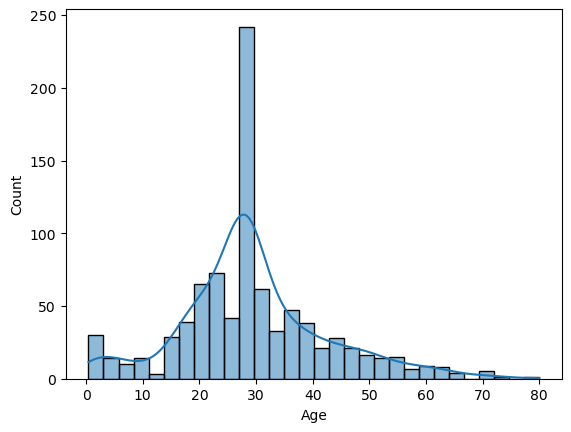

In [10]:
#To view Age distribution
sns.histplot(df['Age'], kde  = True)
plt.show()

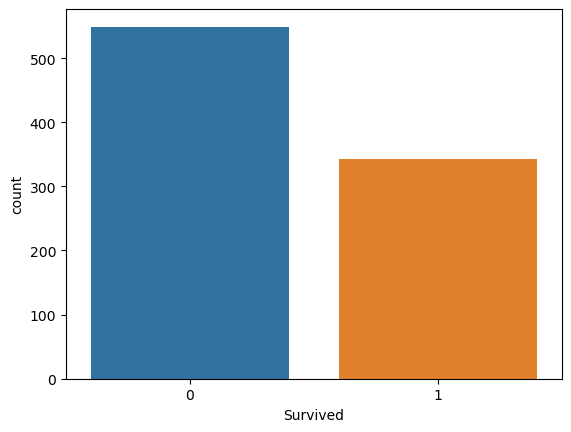

In [11]:
#For the survival rate
sns.countplot(x = 'Survived', data = df)
plt.show()

## Bivariate Analysis 

<Axes: xlabel='Sex', ylabel='Survived'>

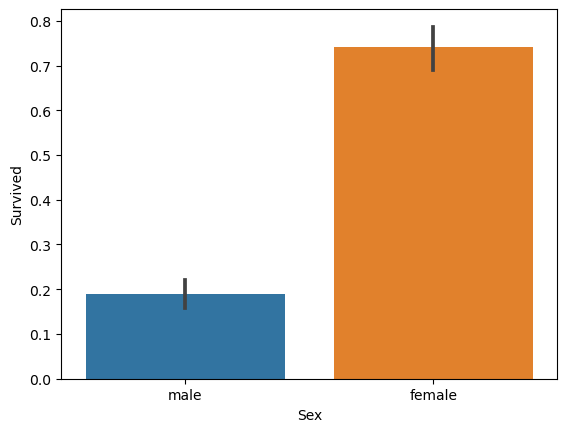

In [12]:
sns.barplot(x ='Sex', y = 'Survived', data=df)


<Axes: xlabel='Pclass', ylabel='Survived'>

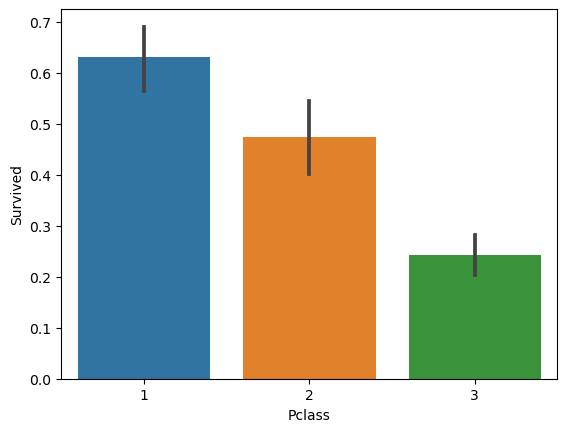

In [19]:
sns.barplot(x ='Pclass', y = 'Survived', data=df)

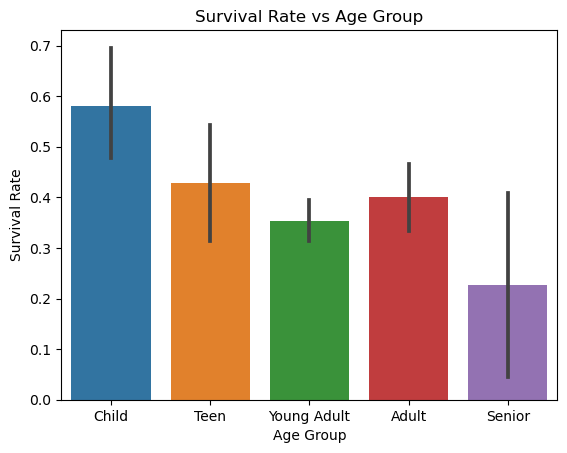

In [14]:
df['AgeGroup'] = pd.cut(df['Age'], bins = [0, 12, 18, 35, 60, 80], labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
sns.barplot(x ='AgeGroup', y = 'Survived', data=df)
plt.title("Survival Rate vs Age Group")
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.show()

## Correlation Analysis

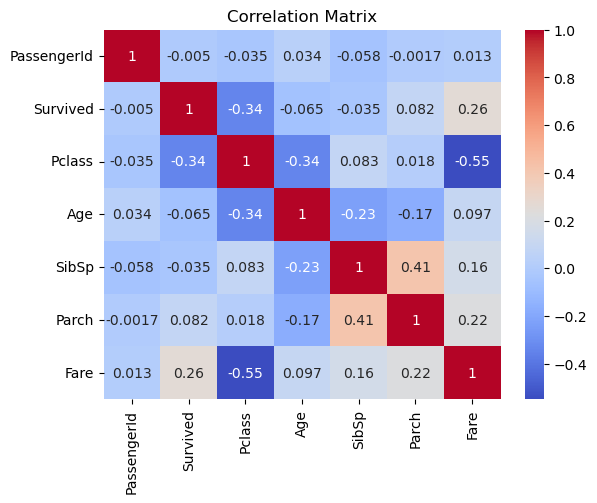

In [22]:
corr = df.corr(numeric_only = True)
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [16]:
df.to_csv("cleaned_titanic.csv", index=False)